# PF-5039: Análisis de Imágenes
## Semana 03 — Tarea Asincrónica (Evaluación Individual)
### Filtrado Espacial Lineal, Gradientes y Detección Multiescala

**Profesor:** Dr. rer. nat. Francisco Siles Canales  
**Programa de Posgrado en Ciencias Biomédicas y Maestría en Ingeniería Eléctrica**  
**Universidad de Costa Rica (UCR)**  
**Semestre:** 2026-II  

---
### Guía e Instrucciones de Entrega:
* La tarea consta de **tres ejercicios de programación aplicada** implementados con rigor matemático y bioinformático.
* **Ponderación Total (100%):**
  * **Ejercicio 1 (35%):** Convolución 2D Separable y Operador Sobel Vectorizado en NumPy (con validación de equivalencia numérica).
  * **Ejercicio 2 (35%):** Detección Multiescala de Microvasculatura Retiniana con Laplaciano de Gaussiana (LoG) y Contraste a Ruido (CNR).
  * **Ejercicio 3 (30%):** Realce de Bordes y Microestructuras con High-Boost Filtering y Cuantificación de Nitidez (Tenengrad).
* **Rigor:** En el **Ejercicio 1** está **estrictamente prohibido** el uso de funciones de alto nivel de OpenCV o SciPy para convolución o gradientes (`cv2.filter2D`, `cv2.Sobel`, `cv2.GaussianBlur`, `scipy.signal.convolve2d`). Debe implementar la convolución 1D y el operador Sobel utilizando **álgebra matricial y vectorización en NumPy**.
* Debe entregar este cuaderno completado con el código fuente y las figuras generadas.

---
### Ejercicio 1 (35%): Implementación Manual en NumPy de Convolución 2D Separable y Operador Sobel

**Fundamento Teórico:**
La convolución separable 1D descompone una operación 2D de tamaño $K \times K$ en dos pasadas unidimensionales consecutivas:
1. **Pasada horizontal (columnas):** $f_{\text{h}}(x,y) = \sum_{s=-a}^{a} v(s)\, f(x-s, y)$ con padding reflejado simétrico (`BORDER_REFLECT_101` / `mode='reflect'`).
2. **Pasada vertical (filas):** $g(x,y) = \sum_{t=-b}^{b} u(t)\, f_{\text{h}}(x, y-t)$.

El operador Sobel $3\times3$ para aproximar las derivadas espaciales $G_x$ y $G_y$ es separable en un vector de suavizado y un vector de derivación:
$$W_{Sx} = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix} \cdot \begin{bmatrix} -1 & 0 & 1 \end{bmatrix}^T$$
$$W_{Sy} = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} = \begin{bmatrix} -1 \\ 0 \\ 1 \end{bmatrix} \cdot \begin{bmatrix} 1 & 2 & 1 \end{bmatrix}^T$$

**Instrucciones:**
1. Cargue la imagen `resonancia_cerebro_mri.png` en escala de grises.
2. Implemente la función `convolucion_1d_numpy(img, kernel_1d, eje)` que aplique una convolución 1D a lo largo de las columnas (`eje=1`) o filas (`eje=0`) con padding reflejado.
3. Implemente la función `sobel_separable_numpy(img)` que calcule $G_x$, $G_y$ y la magnitud $M = \sqrt{G_x^2 + G_y^2}$ usando únicamente NumPy.
4. Valide numéricamente su implementación contra `cv2.Sobel(img, cv2.CV_64F, ...)` calculando el **PSNR** ($> 50\text{ dB}$) y el Error Cuadrático Medio (**MSE** $< 10^{-4}$).

MSE  : 0.0000e+00 (Meta: < 1e-4)
PSNR : 100.00 dB (Meta: > 50 dB)


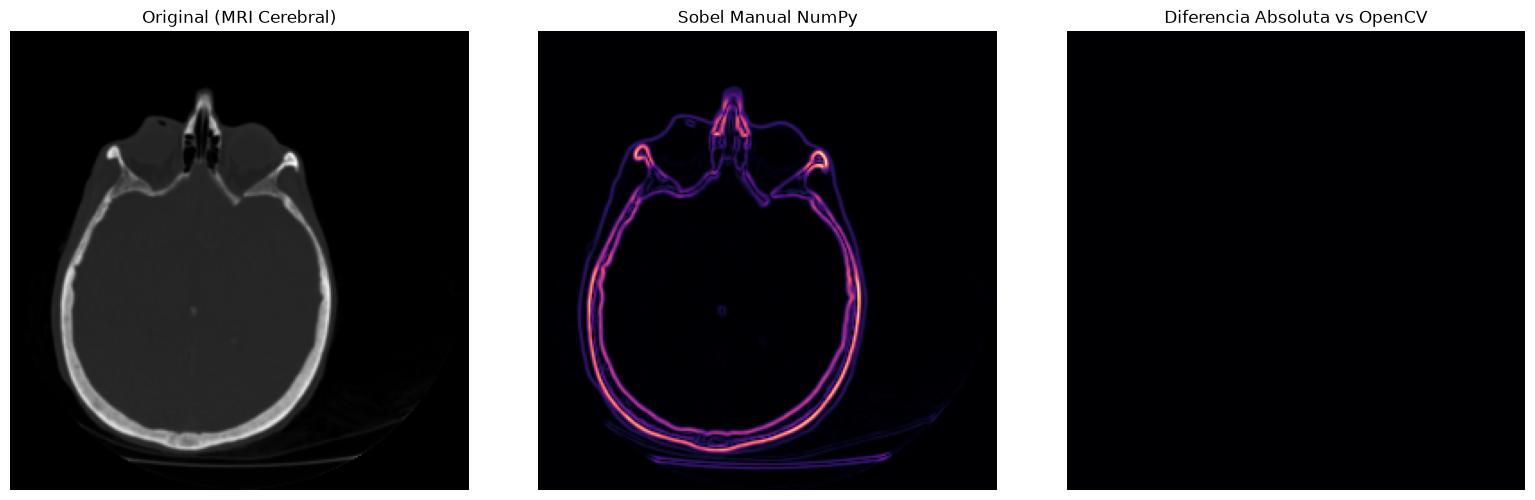

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# Función universal de carga de imágenes biomédicas
def leer_img(ruta, flags=cv2.IMREAD_GRAYSCALE):
    candidatas = [
        ruta,
        os.path.join("..", "..", "Imagenes_Ejemplo", os.path.basename(ruta)),
        os.path.join("..", "Imagenes_Ejemplo", os.path.basename(ruta)),
        os.path.join("Imagenes_Ejemplo", os.path.basename(ruta)),
        os.path.join("2026-II", "Imagenes_Ejemplo", os.path.basename(ruta))
    ]
    for c in candidatas:
        if os.path.exists(c):
            data = np.fromfile(c, dtype=np.uint8)
            img = cv2.imdecode(data, flags)
            if img is not None:
                return img
    raise FileNotFoundError(f"No se encontró la imagen: {ruta}")

img_mri = leer_img("imagenes/resonancia_cerebro_mri.png")

# ==============================================================================
# TODO 1.1: Convolución 1D Vectorizada en NumPy con Padding Reflejado
# ==============================================================================
def convolucion_1d_numpy(img, kernel_1d, eje):
    """
    Aplica convolución 1D sobre una imagen 2D a lo largo de un eje específico.

    Args:
        img (np.ndarray):
            Imagen 2D de entrada.

        kernel_1d (np.ndarray):
            Vector unidimensional de coeficientes.

        eje (int):
            1 para convolución horizontal.
            0 para convolución vertical.

    Returns:
        np.ndarray:
            Imagen filtrada del mismo tamaño que la original en float64.
    """

    # Trabajamos en coma flotante para evitar problemas
    # de saturación o pérdida de signo.
    img = img.astype(np.float64)

    # Convertimos el kernel a un vector NumPy.
    kernel = np.asarray(kernel_1d, dtype=np.float64)

    # Tamaño del kernel.
    K = kernel.size

    # El ejercicio utiliza kernels con tamaño impar.
    if K % 2 == 0:
        raise ValueError("El kernel debe tener un tamaño impar.")

    # Radio del kernel.
    radio = K // 2

    # En una convolución el kernel debe invertirse.
    kernel_flip = kernel[::-1]

    # ----------------------------------------------------------
    # Convolución horizontal
    # ----------------------------------------------------------
    if eje == 1:

        # Padding solamente sobre las columnas.
        img_pad = np.pad(
            img,
            ((0, 0), (radio, radio)),
            mode="reflect"
        )

        # Construimos todas las ventanas horizontales.
        ventanas = np.lib.stride_tricks.sliding_window_view(
            img_pad,
            window_shape=K,
            axis=1
        )

        # Multiplicación por el kernel y acumulación.
        resultado = np.sum(
            ventanas * kernel_flip,
            axis=-1
        )

    # ----------------------------------------------------------
    # Convolución vertical
    # ----------------------------------------------------------
    elif eje == 0:

        # Padding solamente sobre las filas.
        img_pad = np.pad(
            img,
            ((radio, radio), (0, 0)),
            mode="reflect"
        )

        # Construimos todas las ventanas verticales.
        ventanas = np.lib.stride_tricks.sliding_window_view(
            img_pad,
            window_shape=K,
            axis=0
        )

        # Multiplicación por el kernel y acumulación.
        resultado = np.sum(
            ventanas * kernel_flip,
            axis=-1
        )

    else:
        raise ValueError("El eje debe ser 0 (vertical) o 1 (horizontal).")

    return resultado


# ==============================================================================
# TODO 1.2: Operador Sobel Separable Manual en NumPy
# ==============================================================================
def sobel_separable_numpy(img):
    """
    Calcula Gx, Gy y la magnitud del gradiente
    utilizando la descomposición separable de Sobel.

    Args:
        img (np.ndarray):
            Imagen en escala de grises.

    Returns:
        tuple:
            gx, gy y magnitud del gradiente.
    """

    # Vectores base de Sobel.
    k_smooth = np.array([1.0, 2.0, 1.0])
    k_diff   = np.array([-1.0, 0.0, 1.0])

    # ----------------------------------------------------------
    # Gradiente en X
    # ----------------------------------------------------------

    # Primero derivamos horizontalmente.
    gx_horizontal = convolucion_1d_numpy(
        img,
        k_diff,
        eje=1
    )

    # Después suavizamos verticalmente.
    gx = convolucion_1d_numpy(
        gx_horizontal,
        k_smooth,
        eje=0
    )

    # ----------------------------------------------------------
    # Gradiente en Y
    # ----------------------------------------------------------

    # Primero suavizamos horizontalmente.
    gy_horizontal = convolucion_1d_numpy(
        img,
        k_smooth,
        eje=1
    )

    # Después derivamos verticalmente.
    gy = convolucion_1d_numpy(
        gy_horizontal,
        k_diff,
        eje=0
    )

    # ----------------------------------------------------------
    # Magnitud del gradiente
    # ----------------------------------------------------------

    mag = np.sqrt(gx**2 + gy**2)

    return gx, gy, mag

# ==============================================================================
# Celda de Prueba y Validación Numérica (Ejecute para comprobar su resultado)
# ==============================================================================
gx_man, gy_man, mag_man = sobel_separable_numpy(img_mri)

# Referencia oficial de OpenCV (CV_64F con BORDER_REFLECT_101)
gx_cv = cv2.Sobel(img_mri, cv2.CV_64F, 1, 0, ksize=3, borderType=cv2.BORDER_REFLECT_101)
gy_cv = cv2.Sobel(img_mri, cv2.CV_64F, 0, 1, ksize=3, borderType=cv2.BORDER_REFLECT_101)
mag_cv = cv2.magnitude(gx_cv, gy_cv)

val_mse = mse(mag_cv, mag_man)
rango = np.ptp(mag_cv) if np.ptp(mag_cv) > 0 else 1.0
val_psnr = 100.0 if val_mse < 1e-12 else psnr(mag_cv, mag_man, data_range=rango)

print(f"MSE  : {val_mse:.4e} (Meta: < 1e-4)")
print(f"PSNR : {val_psnr:.2f} dB (Meta: > 50 dB)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_mri, cmap='gray'); axes[0].set_title("Original (MRI Cerebral)"); axes[0].axis('off')
axes[1].imshow(mag_man, cmap='magma'); axes[1].set_title("Sobel Manual NumPy"); axes[1].axis('off')
axes[2].imshow(np.abs(mag_cv - mag_man), cmap='inferno'); axes[2].set_title("Diferencia Absoluta vs OpenCV"); axes[2].axis('off')
plt.tight_layout(); plt.show()

---
### Ejercicio 2 (35%): Detección Multiescala de Vasos en Retinografía y Relación Contraste a Ruido (CNR)

**Contexto Clínico:**
En retinografías digitales de fondo de ojo (`retinografia_microaneurismas.png`), los microaneurismas y la microvasculatura periférica presentan diámetros de entre $2$ y $6$ píxeles. Detectar estos vasos requiere sintonizar la escala $\sigma$ del operador Laplaciano de Gaussiana (LoG) para coincidir con la anchura del vaso (adaptación de escala de Lindeberg).

**Instrucciones:**
1. Cargue la imagen `retinografia_microaneurismas.png` en escala de grises.
2. Implemente un análisis de detección de vasos evaluando LoG en 4 escalas: $\sigma \in \{1.0, 2.0, 3.5, 5.0\}$.
   * El tamaño de kernel Gaussiano recomendado es $K = 2 \cdot \lceil 3\sigma \rceil + 1$.
   * Utilice `borderType=cv2.BORDER_REFLECT_101`.
3. Para cada escala, calcule la magnitud absoluta de la respuesta de LoG en coma flotante ($| \nabla^2 f_\sigma |$).
4. Calcule la **Relación Contraste a Ruido (CNR)** para cada escala:
   $$\text{CNR} = \frac{|\mu_{\text{vaso}} - \mu_{\text{fondo}}|}{\sigma_{\text{fondo}}}$$
   donde:
   * $\mu_{\text{vaso}}$ es la media de la respuesta LoG en los píxeles de mayor intensidad (percentil $> 90$).
   * $\mu_{\text{fondo}}$ y $\sigma_{\text{fondo}}$ son la media y desviación estándar de la respuesta en la región tisular de fondo (percentil $< 50$).
5. Grafique las 4 respuestas en un panel de 4 columnas, indicando en el título la escala $\sigma$ y el valor de CNR obtenido.

sigma = 1.0 | kernel = 7x7 | p50 = 0.189376 | p90 = 0.502086 | std_fondo = 0.054974 | CNR = 10.69
sigma = 2.0 | kernel = 13x13 | p50 = 0.132951 | p90 = 0.360233 | std_fondo = 0.037985 | CNR = 11.32
sigma = 3.5 | kernel = 23x23 | p50 = 0.083473 | p90 = 0.246583 | std_fondo = 0.023740 | CNR = 13.22
sigma = 5.0 | kernel = 31x31 | p50 = 0.054004 | p90 = 0.179609 | std_fondo = 0.015383 | CNR = 15.39


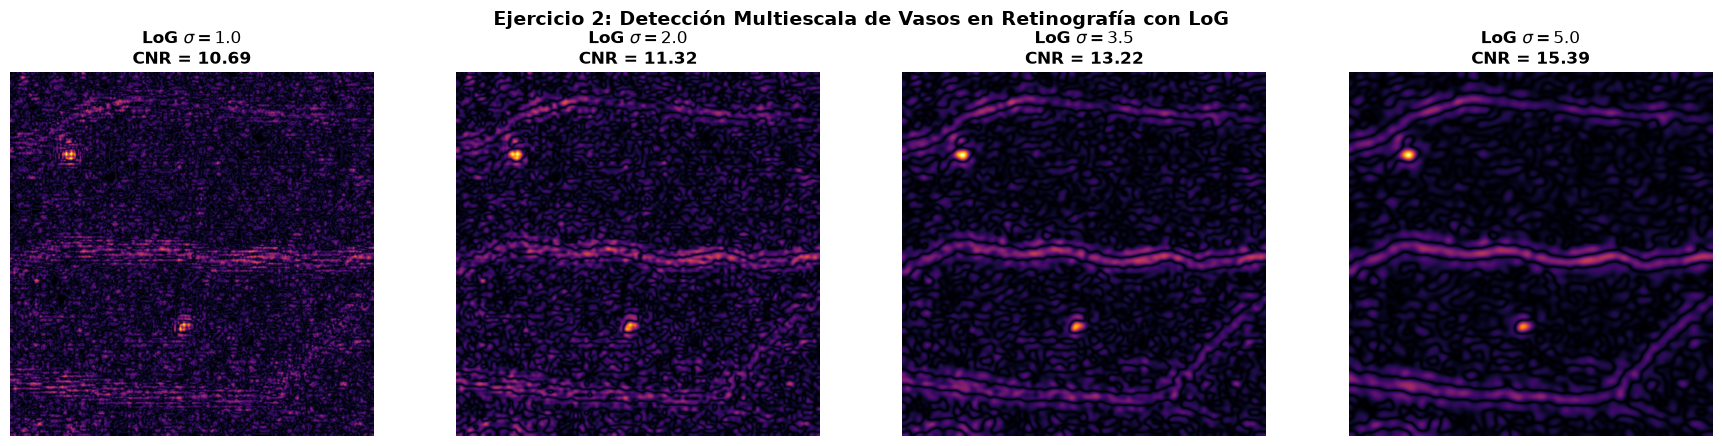

In [15]:
img_retina = leer_img("imagenes/retinografia_microaneurismas.png")

# Trabajamos en coma flotante para evitar cuantización durante el filtrado
img_retina_float = img_retina.astype(np.float64)

# ==============================================================================
# TODO 2: Análisis Multiescala de Vasos con LoG y Cálculo de CNR
# ==============================================================================

sigmas = [1.0, 2.0, 3.5, 5.0]

# Lista para almacenar las imágenes de respuesta LoG
logs_res = []

# Lista para almacenar los valores de CNR por escala
cnrs = []

for s in sigmas:

    # ==========================================================================
    # TODO 2.1:
    # Calcular el tamaño impar del kernel Gaussiano
    #
    # K = 2 * ceil(3 * sigma) + 1
    # ==========================================================================

    ks = int(2 * np.ceil(3 * s) + 1)

    # ==========================================================================
    # TODO 2.2:
    # Suavizar la imagen con un filtro Gaussiano
    # ==========================================================================

    img_suavizada = cv2.GaussianBlur(
        img_retina_float,
        (ks, ks),
        sigmaX=s,
        sigmaY=s,
        borderType=cv2.BORDER_REFLECT_101
    )

    # ==========================================================================
    # TODO 2.3:
    # Aplicar el Laplaciano y obtener el valor absoluto de la respuesta LoG
    # ==========================================================================

    laplaciano = cv2.Laplacian(
        img_suavizada,
        cv2.CV_64F,
        borderType=cv2.BORDER_REFLECT_101
    )

    log_abs = np.abs(laplaciano)

    # Guardar la respuesta LoG de esta escala
    logs_res.append(log_abs)

    # ==========================================================================
    # TODO 2.4:
    # Identificar las regiones de vaso y fondo utilizando percentiles
    # ==========================================================================

    p90 = np.percentile(log_abs, 90)
    p50 = np.percentile(log_abs, 50)

    mascara_vaso = log_abs > p90
    mascara_fondo = log_abs < p50

    # ==========================================================================
    # TODO 2.5:
    # Calcular las estadísticas necesarias para el CNR
    # ==========================================================================

    mu_vaso = np.mean(log_abs[mascara_vaso])
    mu_fondo = np.mean(log_abs[mascara_fondo])
    std_fondo = np.std(log_abs[mascara_fondo])

    # Relación Contraste a Ruido
    cnr = np.abs(mu_vaso - mu_fondo) / std_fondo

    # Guardar el CNR de esta escala
    cnrs.append(cnr)

    # Mostrar resultados numéricos
    print(
        f"sigma = {s:.1f} | "
        f"kernel = {ks}x{ks} | "
        f"p50 = {p50:.6f} | "
        f"p90 = {p90:.6f} | "
        f"std_fondo = {std_fondo:.6f} | "
        f"CNR = {cnr:.2f}"
    )


# ==============================================================================
# Graficar resultados
# ==============================================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for idx, s in enumerate(sigmas):

    axes[idx].imshow(
        logs_res[idx],
        cmap="inferno"
    )

    axes[idx].set_title(
        rf"LoG $\sigma={s:.1f}$" +
        f"\nCNR = {cnrs[idx]:.2f}",
        fontweight="bold"
    )

    axes[idx].axis("off")


plt.suptitle(
    "Ejercicio 2: Detección Multiescala de Vasos en Retinografía con LoG",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---
### Ejercicio 3 (30%): Realce de Bordes mediante High-Boost Filtering y Cuantificación de Nitidez (Tenengrad)

**Contexto Clínico:**
En mamografías digitales (`mamografia.png`), las microcalcificaciones y las espículas malignas son estructuras de alta frecuencia espacial inmersas en tejido fibroglandular denso de bajo contraste. El realce mediante **Unsharp Masking / High-Boost Filtering** amplifica las altas frecuencias espaciales:
$$g(x,y) = f(x,y) + k \cdot f_{\text{mask}}(x,y)$$
donde $f_{\text{mask}}(x,y) = f(x,y) - f_{\text{smooth}}(x,y)$ es la máscara de altas frecuencias obtenida con un filtro Gaussiano ($\sigma=2.0$).
* Si $k=1$, se obtiene el clásico **Unsharp Masking**.
* Si $k > 1$, se denomina **High-Boost Filtering** (enfatiza fuertemente el contraste de detalles finos).

Sin embargo, valores excesivos de $k$ amplifican el ruido cuántico de fotones y generan artefactos de halo (*ringing/overshoot*). Para cuantificar objetivamente la ganancia de nitidez frente al factor $k$, la visión computacional biomédica emplea la **Métrica de Tenengrad** basada en la energía del gradiente de Sobel:
$$\mathcal{T}(I) = \frac{1}{M \cdot N} \sum_{x=1}^{M} \sum_{y=1}^{N} \left( G_x(x,y)^2 + G_y(x,y)^2 \right)$$

**Instrucciones:**
1. Cargue `mamografia.png` en escala de grises.
2. Genere la máscara de altas frecuencias $f_{\text{mask}}$ utilizando un filtro Gaussiano con $\sigma=2.0$.
3. Aplique High-Boost Filtering evaluando 4 factores de realce: $k \in \{0.0, 0.8, 1.8, 3.0\}$, asegurando truncamiento de rango con `np.clip(..., 0, 255)`.
4. Implemente una función `calcular_tenengrad(img)` que compute la métrica $\mathcal{T}(I)$ usando derivadas de Sobel en coma flotante.
5. Grafique en un panel:
   * Los 4 resultados visuales con su respectivo puntaje Tenengrad.
   * La curva cuantitativa de Tenengrad vs Factor $k$, identificando el punto donde el realce de bordes empieza a verse dominado por grano de ruido.

In [ ]:
img_mamo = leer_img("imagenes/mamografia.png")

# ==============================================================================
# TODO 3.1: Función para calcular la Métrica de Nitidez de Tenengrad
# ==============================================================================

def calcular_tenengrad(img):
    """
    Calcula la nitidez media basada en la energía del gradiente de Sobel:

        T = mean(Gx^2 + Gy^2)

    Args:
        img (np.ndarray):
            Imagen 2D de entrada.

    Returns:
        float:
            Valor medio de Tenengrad.
    """

    # Derivada espacial horizontal
    gx = cv2.Sobel(
        img,
        cv2.CV_64F,
        1,
        0,
        ksize=3,
        borderType=cv2.BORDER_REFLECT_101
    )

    # Derivada espacial vertical
    gy = cv2.Sobel(
        img,
        cv2.CV_64F,
        0,
        1,
        ksize=3,
        borderType=cv2.BORDER_REFLECT_101
    )

    # Energía del gradiente
    energia_gradiente = gx**2 + gy**2

    # Promedio sobre todos los píxeles
    tenengrad = np.mean(energia_gradiente)

    return tenengrad


# ==============================================================================
# TODO 3.2: Implementación de High-Boost Filtering
# ==============================================================================

sigma_hb = 2.0
k_values = [0.0, 0.8, 1.8, 3.0]

# Trabajamos en coma flotante para evitar pérdida de precisión
mamo_float = img_mamo.astype(np.float64)


# ==============================================================================
# TODO 3.2a:
# Calcular la imagen suavizada con un filtro Gaussiano
# ==============================================================================

mamo_smooth = cv2.GaussianBlur(
    mamo_float,
    (0, 0),
    sigmaX=sigma_hb,
    sigmaY=sigma_hb,
    borderType=cv2.BORDER_REFLECT_101
)


# ==============================================================================
# TODO 3.2b:
# Obtener la máscara de altas frecuencias
#
# f_mask = f - f_smooth
# ==============================================================================

f_mask = mamo_float - mamo_smooth


# ==============================================================================
# TODO 3.2c y 3.2d:
# Aplicar High-Boost para cada k y calcular Tenengrad
# ==============================================================================

imagenes_hb = []
scores_t = []

for k in k_values:

    # High-Boost:
    # g = f + k * f_mask
    f_hb = mamo_float + k * f_mask

    # Limitar las intensidades al rango válido [0, 255]
    f_hb = np.clip(
        f_hb,
        0,
        255
    ).astype(np.uint8)

    # Guardar imagen
    imagenes_hb.append(f_hb)

    # Calcular Tenengrad
    score = calcular_tenengrad(f_hb)

    # Guardar puntaje
    scores_t.append(score)

    print(
        f"k = {k:.1f} | "
        f"Tenengrad = {score:.2f}"
    )


# ==============================================================================
# Graficar las cuatro imágenes High-Boost
# ==============================================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4.5)
)

for idx, k in enumerate(k_values):

    axes[idx].imshow(
        imagenes_hb[idx],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[idx].set_title(
        f"High-Boost (k={k:.1f})\n"
        f"Tenengrad = {scores_t[idx]:.1f}",
        fontweight="bold"
    )

    axes[idx].axis("off")


plt.suptitle(
    "Ejercicio 3: Realce High-Boost en Mamografía y Métrica de Tenengrad",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ==============================================================================
# Graficar curva Tenengrad vs Factor k
# ==============================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    scores_t,
    marker="o"
)

plt.xlabel("Factor de realce k")
plt.ylabel("Tenengrad")

plt.title(
    "Tenengrad vs Factor de Realce High-Boost",
    fontweight="bold"
)

plt.grid(True)

plt.show()

FileNotFoundError: No se encontró la imagen: mamografia.png